In [9]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

# Esto toma automáticamente el nombre del archivo que subiste
nombre_archivo = list(uploaded.keys())[0]

df = pd.read_csv(nombre_archivo)

# Ver datos
print("Filas y columnas:", df.shape)
print("Cantidad de datos (filas):", df.shape[0])

Saving Video Games Sales (1980-2024) - Raw.csv to Video Games Sales (1980-2024) - Raw (1).csv
Filas y columnas: (64016, 14)
Cantidad de datos (filas): 64016


In [10]:
df.head()
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [11]:
df = df.drop(columns=['img', 'critic_score', 'publisher', 'release_date', 'last_update'])


print(df.isnull().sum())

df = df.dropna(subset=['total_sales', 'genre', 'console', 'developer'])

# Verificar que ya no hay nulos relevantes
print(df.isnull().sum())

title              0
console            0
genre              0
developer         17
total_sales    45094
na_sales       51379
jp_sales       57290
pal_sales      51192
other_sales    48888
dtype: int64
title              0
console            0
genre              0
developer          0
total_sales        0
na_sales        6283
jp_sales       12192
pal_sales       6097
other_sales     3793
dtype: int64


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Umbral de éxito: 0.3475

Distribución del target:
exito
0    14188
1     4730
Name: count, dtype: int64

Top developers:
developer_clean
Other                 15769
Unknown                 435
Konami                  409
Capcom                  294
EA Canada               292
Bandai Namco Games      209
Ubisoft                 196
EA Tiburon              193
Ubisoft Montreal        172
Sega                    155
Traveller's Tales       152
Omega Force             145
Visual Concepts         134
Idea Factory            126
Namco Bandai Games      123
Namco                   114
Name: count, dtype: int64

Consolas válidas: 21
Géneros válidos: 15


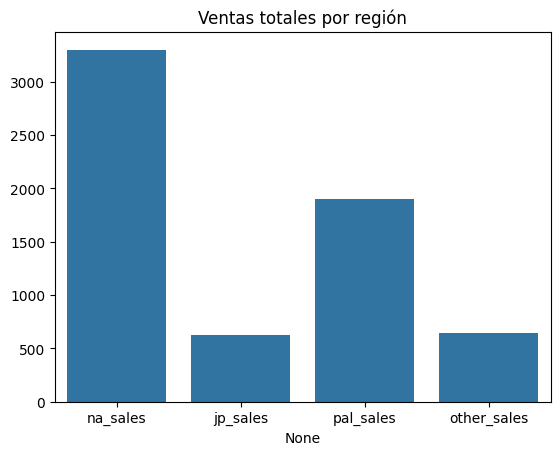

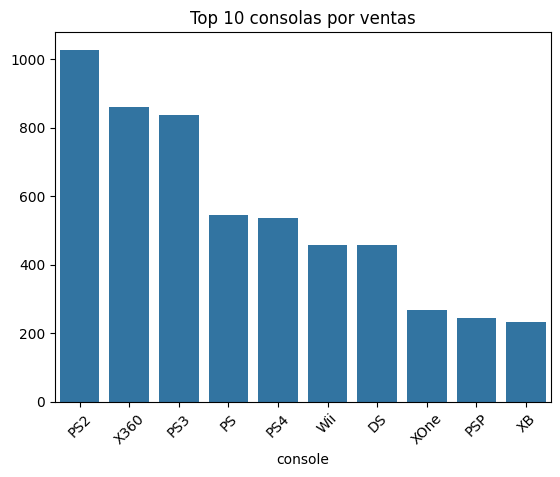


Top consolas:
console
PS2     1027.12
X360     859.03
PS3      838.24
PS       546.25
PS4      535.58
Wii      459.04
DS       457.94
XOne     267.28
PSP      244.82
XB       231.96
Name: total_sales, dtype: float64


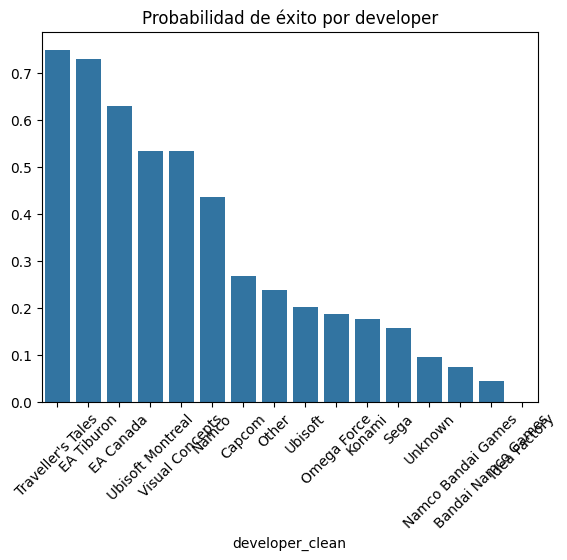


Éxito por developer:
developer_clean
Traveller's Tales     0.750000
EA Tiburon            0.730570
EA Canada             0.630137
Ubisoft Montreal      0.534884
Visual Concepts       0.534351
Namco                 0.436893
Capcom                0.268116
Other                 0.237927
Ubisoft               0.202073
Omega Force           0.186207
Konami                0.175573
Sega                  0.157534
Unknown               0.095128
Namco Bandai Games    0.073770
Bandai Namco Games    0.043269
Idea Factory          0.000000
Name: exito, dtype: float64


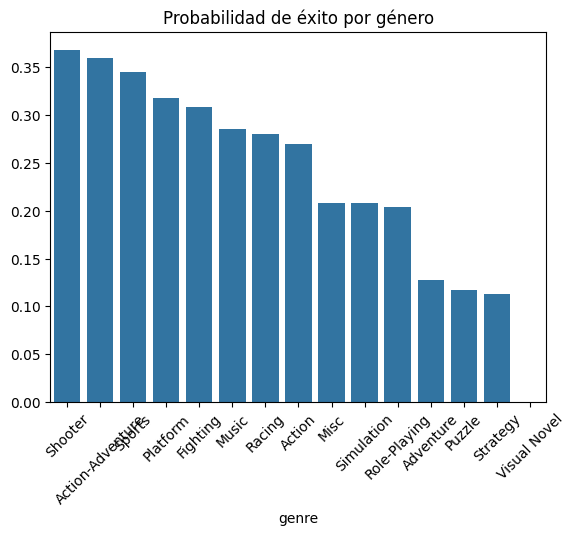


Éxito por género:
genre
Shooter             0.368207
Action-Adventure    0.359848
Sports              0.345016
Platform            0.318430
Fighting            0.309069
Music               0.285714
Racing              0.280677
Action              0.269340
Misc                0.208333
Simulation          0.208259
Role-Playing        0.204249
Adventure           0.128068
Puzzle              0.117564
Strategy            0.112624
Visual Novel        0.000000
Name: exito, dtype: float64

Éxito por consola (con count):
             mean  count
console                 
2600     0.634921    126
PS3      0.404762   1344
X360     0.396459   1299
PS       0.373451   1130
SNES     0.365482    197
PS2      0.363636   2123
N64      0.347670    279
WiiU     0.294964    139
XOne     0.292308    520
Wii      0.281919   1355


In [15]:
# =========================
# 0. TARGET (EXITO)
# =========================
if 'exito' not in df.columns:
    umbral = df['total_sales'].quantile(0.75)
    df['exito'] = (df['total_sales'] > umbral).astype(int)

print("Umbral de éxito:", umbral)
print("\nDistribución del target:")
print(df['exito'].value_counts())

# =========================
# 1. LIMPIEZA DE DEVELOPER
# =========================
top_devs = df['developer'].value_counts().head(15).index

df['developer_clean'] = df['developer'].apply(
    lambda x: x if x in top_devs else 'Other'
)

print("\nTop developers:")
print(df['developer_clean'].value_counts())

# =========================
# 2. FILTRAR RUIDO (CLAVE)
# =========================
# Consolas con suficientes datos
console_counts = df['console'].value_counts()
valid_consoles = console_counts[console_counts > 100].index
df = df[df['console'].isin(valid_consoles)]

# Géneros con suficientes datos
genre_counts = df['genre'].value_counts()
valid_genres = genre_counts[genre_counts > 50].index
df = df[df['genre'].isin(valid_genres)]

print("\nConsolas válidas:", len(valid_consoles))
print("Géneros válidos:", len(valid_genres))

# =========================
# 3. VENTAS POR REGIÓN (SOLO CONTEXTO)
# =========================
region_sales = df[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']].sum()

sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title('Ventas totales por región')
plt.show()

# =========================
# 4. TOP CONSOLAS
# =========================
console_sales = df.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=console_sales.index, y=console_sales.values)
plt.xticks(rotation=45)
plt.title('Top 10 consolas por ventas')
plt.show()

print("\nTop consolas:")
print(console_sales)

# =========================
# 5. ÉXITO POR DEVELOPER
# =========================
success_dev = df.groupby('developer_clean')['exito'].mean().sort_values(ascending=False)

sns.barplot(x=success_dev.index, y=success_dev.values)
plt.xticks(rotation=45)
plt.title('Probabilidad de éxito por developer')
plt.show()

print("\nÉxito por developer:")
print(success_dev)

# =========================
# 6. ÉXITO POR GÉNERO
# =========================
success_genre = df.groupby('genre')['exito'].mean().sort_values(ascending=False)

sns.barplot(x=success_genre.index, y=success_genre.values)
plt.xticks(rotation=45)
plt.title('Probabilidad de éxito por género')
plt.show()

print("\nÉxito por género:")
print(success_genre)

# =========================
# 7. ÉXITO POR CONSOLA (CORRECTO)
# =========================
success_console = df.groupby('console')['exito'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

print("\nÉxito por consola (con count):")
print(success_console.head(10))

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# 1. VARIABLES
# =========================
X = df[['genre', 'console', 'developer_clean']]
y = df['exito']

# =========================
# 2. ONE HOT ENCODING (CLAVE)
# =========================
X = pd.get_dummies(X, drop_first=True)

print("Variables después de encoding:")
print(X.head())

# =========================
# 3. TRAIN / TEST
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. ESCALADO (OPCIONAL PERO RECOMENDADO)
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 5. MODELO (CLAVE)
# =========================
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

# =========================
# 6. PREDICCIÓN
# =========================
y_pred = model.predict(X_test)

# =========================
# 7. MÉTRICAS
# =========================
print("\n===== RESULTADOS =====")

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Variables después de encoding:
   genre_Action-Adventure  genre_Adventure  genre_Fighting  genre_Misc  \
0                   False            False           False       False   
1                   False            False           False       False   
2                   False            False           False       False   
3                   False            False           False       False   
4                   False            False           False       False   

   genre_Music  genre_Platform  genre_Puzzle  genre_Racing  \
0        False           False         False         False   
1        False           False         False         False   
2        False           False         False         False   
3        False           False         False         False   
4        False           False         False         False   

   genre_Role-Playing  genre_Shooter  ...  developer_clean_Namco  \
0               False          False  ...                  False   
1              

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# 1. MODELO KNN
# =========================
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

# =========================
# 2. PREDICCIÓN
# =========================
y_pred_knn = knn.predict(X_test)

# =========================
# 3. MÉTRICAS
# =========================
print("\n===== RESULTADOS KNN =====")

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred_knn))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_knn))


===== RESULTADOS KNN =====

Accuracy:
0.7459038409884502

Matriz de confusión:
[[2500  313]
 [ 633  277]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84      2813
           1       0.47      0.30      0.37       910

    accuracy                           0.75      3723
   macro avg       0.63      0.60      0.61      3723
weighted avg       0.72      0.75      0.73      3723



In [18]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# 1. MODELO BAYES
# =========================
nb = BernoulliNB()

nb.fit(X_train, y_train)

# =========================
# 2. PREDICCIÓN
# =========================
y_pred_nb = nb.predict(X_test)

# =========================
# 3. MÉTRICAS
# =========================
print("\n===== RESULTADOS NAIVE BAYES =====")

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred_nb))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_nb))


===== RESULTADOS NAIVE BAYES =====

Accuracy:
0.7526188557614827

Matriz de confusión:
[[2613  200]
 [ 721  189]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85      2813
           1       0.49      0.21      0.29       910

    accuracy                           0.75      3723
   macro avg       0.63      0.57      0.57      3723
weighted avg       0.71      0.75      0.71      3723

